# Customer Dataset Classification with Visualizations

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [3]:

# Load dataset
df = pd.read_csv('../FILES_MAIN/customer_data.csv')
df.head()


,Customer_ID,Age,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeat,NumWebPurchases,NumStorePurchases,Response
0,1,57,54808,1,0,36,340,430,88,16,2,0
1,2,63,85728,0,0,47,883,320,550,18,5,0
2,3,55,32118,1,0,72,785,325,448,16,15,1
3,4,27,90522,1,0,69,117,361,480,16,16,1
4,5,48,53798,2,1,20,264,255,120,15,2,1


In [4]:

# Basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Customer_ID        500 non-null    int64
 1   Age                500 non-null    int64
 2   Income             500 non-null    int64
 3   Kidhome            500 non-null    int64
 4   Teenhome           500 non-null    int64
 5   Recency            500 non-null    int64
 6   MntWines           500 non-null    int64
 7   MntFruits          500 non-null    int64
 8   MntMeat            500 non-null    int64
 9   NumWebPurchases    500 non-null    int64
 10  NumStorePurchases  500 non-null    int64
 11  Response           500 non-null    int64
dtypes: int64(12)
memory usage: 47.0 KB


In [5]:

# Handle missing values
df = df.dropna()


In [6]:

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])


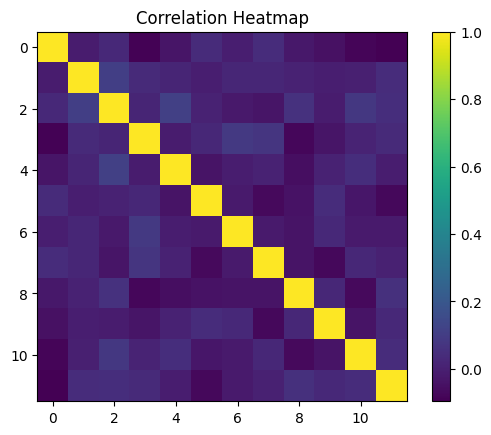

In [7]:

# Correlation heatmap
corr = df.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()


In [8]:

# Target column (change if needed)
target = df.columns[-1]

X = df.drop(columns=[target])
y = df[target]


In [9]:

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [11]:

# Model training
model = RandomForestClassifier()
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:

# Predictions
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.48

Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.41      0.40        41
           1       0.56      0.53      0.54        59

    accuracy                           0.48       100
   macro avg       0.47      0.47      0.47       100
weighted avg       0.49      0.48      0.48       100



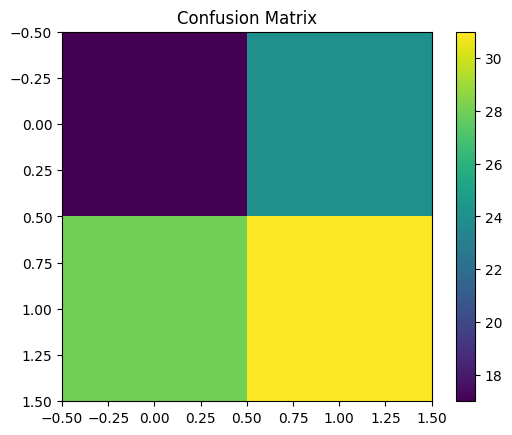

In [13]:

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()


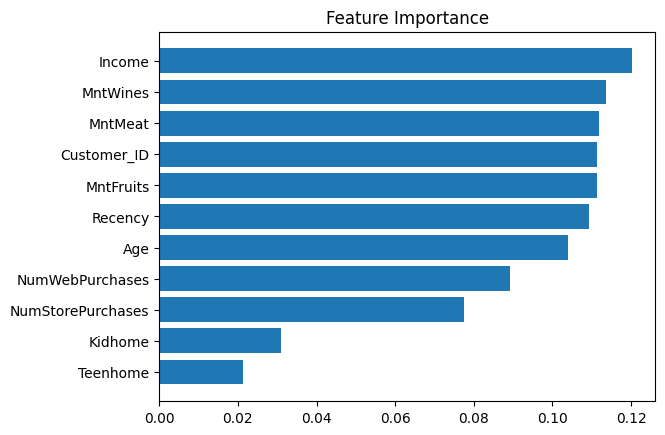

In [14]:

# Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Feature Importance")
plt.show()
